# Einleitung
Im Rahmen des Data-Lab-Kurses wurde ein Machine-Learning‑Projekt entwickelt, das den praktischen Nutzen von Bildklassifikation im Kontext der Mülltrennung untersucht. Ziel des Projekts ist es, anhand von Bilddaten automatisiert zu erkennen, zu welcher Abfallkategorie ein Objekt gehört. Damit adressiert das Projekt ein reales Problem: Fehlwürfe im Abfall führen zu hohen Sortierkosten, mindern die Recyclingqualität und erschweren ressourceneffizientes Handeln. Ein KI‑gestütztes System könnte hier einen Beitrag leisten, indem es Nutzerinnen und Nutzer im Alltag unterstützt oder Sortierprozesse teilautomatisiert.
Ein zentraler Bestandteil des Projekts ist eine saubere und reproduzierbare Datenvorbereitung, die die Grundlage für jedes verlässliche Klassifikationsmodell bildet. Dieser Prozess umfasst die Sichtung, Analyse und Strukturierung des Datensatzes, das Vereinheitlichen der Bildgrößen, das Erstellen eines Train‑Validation‑Test‑Splits sowie das Generieren künstlich erweiterter Trainingsdaten durch Datenaugmentation. Durch diesen systematischen Workflow wurde ein qualitativ hochwertiger, konsistenter und modellfertiger Datensatz aufgebaut, der von der Modellgruppe zur Entwicklung eines neuronalen Klassifikators genutzt werden kann.
Damit leistet das Projekt nicht nur einen Beitrag zum Verständnis moderner Machine‑Learning‑Pipelines, sondern verbindet technische Methodenkompetenz mit einem gesellschaftlich relevanten Anwendungsfall.

# 1. Setup & Bibliotheken

In diesem Schritt laden wir alle benötigten Bibliotheken

In [2]:
import os    #Zugriff auf Ordner, Dateien einlesen
import matplotlib.pyplot as plt     #Diagramme und Bilder anzeigen
from PIL import Image   #Bilder öffnen, bearbeiten, verarbeiten
import random
from collections import Counter
from sklearn.model_selection import train_test_split
import shutil

# 2. Projektpfad setzen und Datensatz prüfen

Wir setzen das Arbeitsverzeichnis auf unseren Projektordner und prüfen, ob der Ordner `dataset-resized`gefunden wird.

In [4]:
# Name des Ordners, der gefunden werden muss
DATASET_DIR = "dataset-resized"

def find_project_root(start_path):
    """
    Läuft vom gegebenen Startpfad nach oben,
    bis der Ordner 'dataset-resized' gefunden wird.
    """
    current = start_path
    while True:
        if DATASET_DIR in os.listdir(current):
            return current
        # Eine Ebene höher gehen
        parent = os.path.dirname(current)
        if parent == current:
            # Root erreicht, nicht gefunden
            return None
        current = parent

# 1. Aktuellen Pfad anzeigen
print("Aktueller Arbeitsordner:", os.getcwd())

# 2. Projektordner automatisch suchen
project_root = find_project_root(os.getcwd())

if project_root is None:
    raise FileNotFoundError(f"'{DATASET_DIR}' konnte nicht gefunden werden.")

# 3. Arbeitsverzeichnis setzen (nur wenn nötig)
if os.getcwd() != project_root:
    os.chdir(project_root)
    print("Arbeitsverzeichnis automatisch gesetzt auf:", project_root)
else:
    print("Arbeitsverzeichnis war schon korrekt gesetzt.")

# 4. Finaler Check
print("dataset-resized gefunden:", os.path.isdir(DATASET_DIR))
print("Inhalt:", os.listdir())

Aktueller Arbeitsordner: c:\Users\GOICY\OneDrive - Bayer\00 Persönlich\03 FHDW\Data Lab\DataLabTrash\src
Arbeitsverzeichnis automatisch gesetzt auf: c:\Users\GOICY\OneDrive - Bayer\00 Persönlich\03 FHDW\Data Lab\DataLabTrash
dataset-resized gefunden: True
Inhalt: ['.git', 'dataset-224', 'dataset-augmented', 'dataset-resized', 'dataset-split', 'README.md', 'requirements.txt', 'src']


# Löschen alter Ordner (Reset Code, bevor Bilder verarbeitet werden)
⭐ Richtige Reihenfolge – ganz einfach erklärt

🟩 1. ZUERST: Projektpfad automatisch setzen
Damit weiß der Kernel überhaupt, wo er sich befindet → sonst löscht er am falschen Ort!
✔ also zuerst:

automatisches Finden des Projektordners
os.chdir(...) → Arbeitsverzeichnis setzen
prüfen: dataset-resized gefunden: True


🟩 2. DANN: automatische Ordner-Löschung (Reset)
Wenn der Projektpfad stimmt, kannst du gefahrlos löschen:

dataset-224
dataset-split
dataset-augmented

Warum erst jetzt?
Weil der Kernel zu diesem Zeitpunkt garantiert im richtigen Ordner ist — du löscht also nichts Falsches.

🟩 3. DANACH: Pipeline starten (Resize → Split → Augment)
Jetzt kannst du sicher:

Resizing, Split und Augmentation neu erstellen, ohne doppelte Ordner und ohne Fehler wie „Ordner nicht gefunden“, „dataset-224 ist leer“, „Split ist unvollständig“, „alte augmentierte Bilder wurden nicht überschrieben“

In [14]:
#Version fragt vorher nach
import shutil
import os
import stat


def handle_remove_readonly(func, path, exc):
    # Entsperrt schreibgeschützte Dateien/Ordner
    os.chmod(path, stat.S_IWRITE)
    func(path)

folders_to_reset = ["dataset-224", "dataset-split", "dataset-augmented"]

user_input = input("Ordner neu erzeugen? (j/n): ")

if user_input.lower() == "j":
    for folder in folders_to_reset:
        if os.path.exists(folder):
            shutil.rmtree(folder, onerror=handle_remove_readonly)
            print(f"Gelöscht: {folder}")
        else:
            print(f"Nicht vorhanden (ok): {folder}")
else:
    print("Reset übersprungen.")

Gelöscht: dataset-224
Gelöscht: dataset-split
Gelöscht: dataset-augmented


In [ ]:
#andere Version
folders_to_reset = ["dataset-224", "dataset-split", "dataset-augmented"]

for folder in folders_to_reset:
    if os.path.exists(folder):
        shutil.rmtree(folder)
        print(f"Gelöscht: {folder}")
    else:
        print(f"Nicht vorhanden (ok): {folder}")

PermissionError: [WinError 5] Zugriff verweigert: 'dataset-224\\cardboard'

# 3. Klassen automatisch einlesen

Wir lesen die vorhandenen Klassen automatisch ein – dadurch bleibt der Workflow flexibel, falls neue Kategorien hinzukommen.

In [5]:
classes = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])


# 4. Beispielbilder anzeigen

Wir zeigen je Klasse einige Beispielbilder, um die Datenqualität zu prüfen.

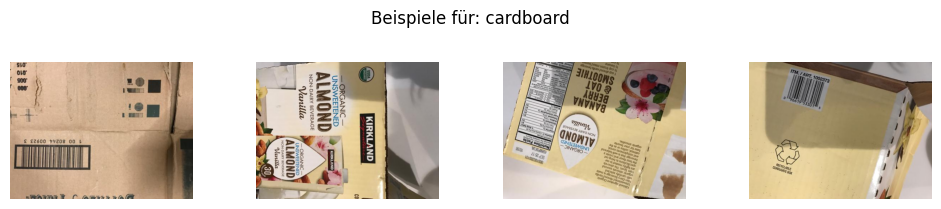

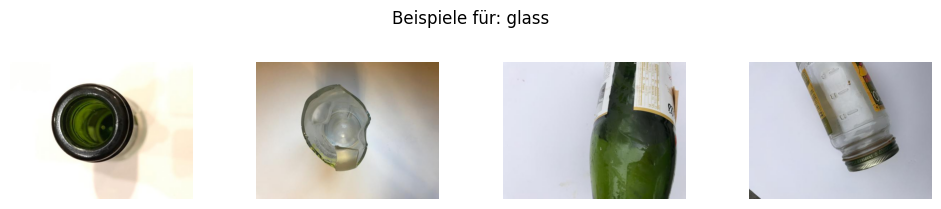

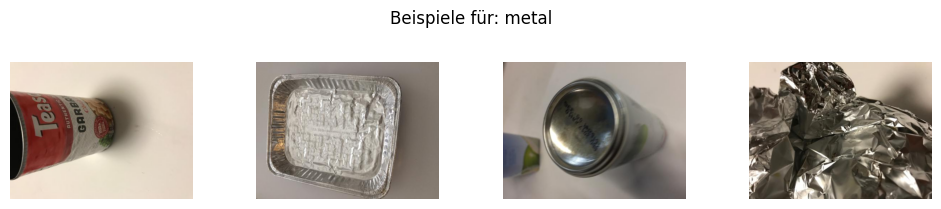

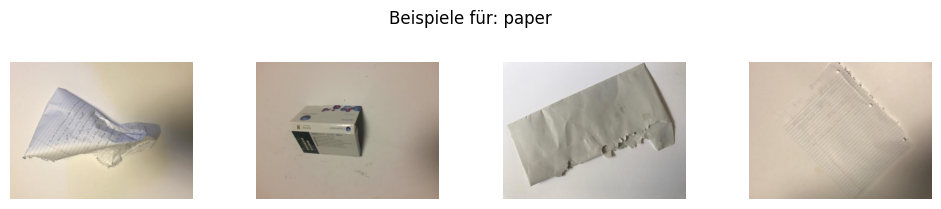

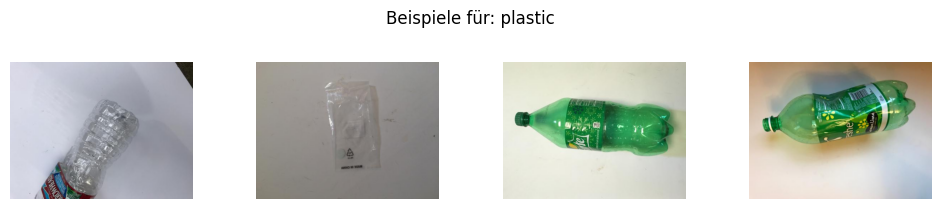

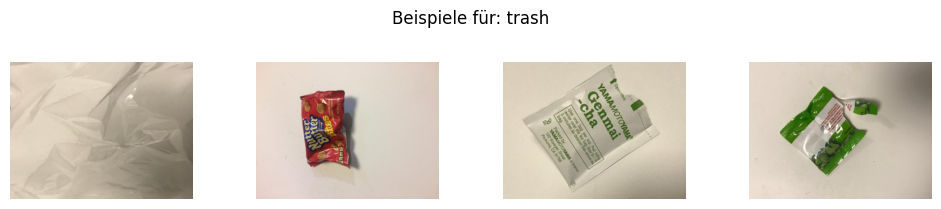

In [9]:
def show_examples(cls, n=4):
    folder = os.path.join(DATASET_DIR, cls)
    files = random.sample(os.listdir(folder), n)

    plt.figure(figsize=(10, 2))

    for i, file in enumerate(files):
        img = Image.open(os.path.join(folder, file))
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")

    # Titel
    plt.suptitle(f"Beispiele für: {cls}", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()


# 4 Beispielbilder für alle Klassen anzeigen
for cls in classes:
    show_examples(cls, n=4)

# 5. Bildgrößen analysieren (optional)

Wir analysieren die Bildgrößen und die Häufigkeit der Bildgrößen. Das ist wichtig, bevor wir sie auf eine einheitliche Zielgröße (224×224) skalieren.

In [10]:
sizes = []

for cls in classes:
    folder = os.path.join(DATASET_DIR, cls)
    for file in os.listdir(folder):
        img = Image.open(os.path.join(folder, file))
        sizes.append(img.size)

Counter(sizes).most_common(10)

[((512, 384), 2527)]

<function matplotlib.pyplot.show(close=None, block=None)>

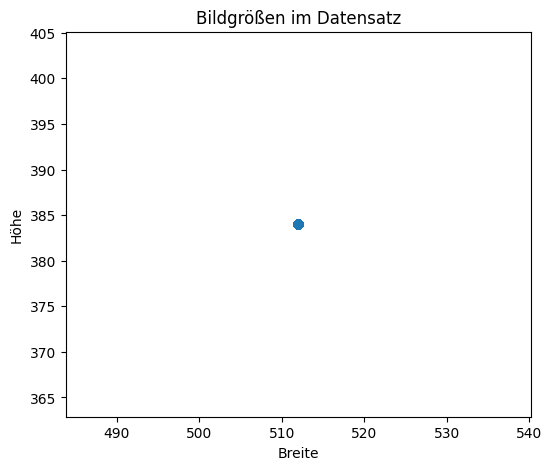

In [11]:
#Bildgrößen als Plot anzeigen
widths = [w for (w,h) in sizes]
heights = [h for (w,h) in sizes]

plt.figure(figsize=(6,5))
plt.scatter(widths, heights, alpha=0.3)
plt.xlabel("Breite")
plt.ylabel("Höhe")
plt.title("Bildgrößen im Datensatz")
plt.show

# 6. Resizing auf 224×224

Wir skalieren alle Bilder auf eine einheitliche Größe von 224×224 Pixeln und speichern sie im Ordner `dataset-224`.

INPUT_DIR = "dataset-resized"   #Original Ordner
OUTPUT_DIR = "dataset-224"      #Zielordner
TARGET_SIZE = (224, 224)        #Zielgröße

#Zielordner erstellen
os.makedirs(OUTPUT_DIR, exist_ok=True)

for cls in classes:
    #Ordner für die Klassen im Zielverzeichnis anlegen
    input_class = os.path.join(INPUT_DIR, cls)
    output_class = os.path.join(OUTPUT_DIR, cls)
    os.makedirs(output_class, exist_ok=True)

    #Alle Bilder durchgehen
    for file in os.listdir(input_class):
        # Bild öffnen und konvertieren
        img = Image.open(os.path.join(input_class, file)).convert("RGB")
        # Resizing durchführen
        img = img.resize(TARGET_SIZE)
        # Bild speichern
        img.save(os.path.join(output_class, file))

print("Resize abgeschlossen. Alle Bilder wurden nach dataset-224 resized.")

# 7. Train/Validation/Test Split

Wir splitten den Datensatz in 70% Training, 15% Validation und 15% Test.

INPUT_DIR = "dataset-224"
OUTPUT_BASE = "dataset-split"

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(OUTPUT_BASE, split, cls), exist_ok=True)

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

for cls in classes:
    files = os.listdir(os.path.join(INPUT_DIR, cls))
    
    train_files, temp_files = train_test_split(
        files, test_size=(1-train_ratio), random_state=42
    )
    val_files, test_files = train_test_split(
        temp_files, test_size=(test_ratio/(test_ratio+val_ratio)), random_state=42
    )

    for f in train_files:
        shutil.copy(os.path.join(INPUT_DIR, cls, f), os.path.join(OUTPUT_BASE, "train", cls, f))
    for f in val_files:
        shutil.copy(os.path.join(INPUT_DIR, cls, f), os.path.join(OUTPUT_BASE, "val", cls, f))
    for f in test_files:
        shutil.copy(os.path.join(INPUT_DIR, cls, f), os.path.join(OUTPUT_BASE, "test", cls, f))

print("Split abgeschlossen!")

# 8. Datenaugmentation

Wir erweitern die Trainingsdaten um Rotation, Spiegelung und Helligkeits-/Kontrastvariationen.

from PIL import ImageEnhance

INPUT_DIR = "dataset-split/train"
OUTPUT_DIR = "dataset-augmented/train"

os.makedirs(OUTPUT_DIR, exist_ok=True)

def augment_image(img):
    if random.random() < 0.5:
        img = img.rotate(random.randint(-15, 15))
    if random.random() < 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
    if random.random() < 0.4:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.7, 1.3))
    if random.random() < 0.4:
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.7, 1.3))
    return img

for cls in classes:
    input_class = os.path.join(INPUT_DIR, cls)
    output_class = os.path.join(OUTPUT_DIR, cls)
    os.makedirs(output_class, exist_ok=True)

    for file in os.listdir(input_class):
        img = Image.open(os.path.join(input_class, file))

        img.save(os.path.join(output_class, file))

        for i in range(2):
            aug = augment_image(img.copy())
            base, ext = os.path.splitext(file)
            aug.save(os.path.join(output_class, f"{base}_aug{i}{ext}"))

print("Augmentation fertig!")

# Fazit
Das durchgeführte Data‑Lab‑Projekt zeigt, wie wichtig eine strukturierte und transparente Datenvorbereitung für den Erfolg eines Machine‑Learning‑Modells ist. Durch die Vereinheitlichung der Bildgrößen, die gezielte Aufteilung in Trainings-, Validierungs- und Testmengen sowie die datenbasierte Erweiterung mittels Augmentation konnte ein belastbarer und vielseitiger Datensatz geschaffen werden. Dieser bildet die Grundlage für ein robustes neuronales Modell, das in der Lage ist, verschiedene Abfalltypen zuverlässig zu unterscheiden.
Darüber hinaus verdeutlicht das Projekt, dass Data‑Preparation weit mehr ist als ein technischer Zwischenschritt: Sie entscheidet maßgeblich über die Modellqualität, die Trainingsstabilität und die spätere Anwendbarkeit der KI. Die im Projekt durchlaufenen Schritte – Datenverständnis, Qualitätssicherung, Bereinigung, Transformation und Erweiterung – spiegeln zentrale Best Practices der modernen Datenwissenschaft wider und zeigen, wie theoretisches Wissen praktisch eingesetzt wird.
Durch den klaren Bezug zur realen Herausforderung der Mülltrennung wird zugleich sichtbar, wie Machine Learning konkrete gesellschaftliche Probleme adressieren kann. Das Projekt liefert damit nicht nur einen funktionierenden technischen Workflow, sondern auch ein Beispiel dafür, wie datengetriebene Lösungen Nachhaltigkeit und Alltagsprozesse unterstützen können.